# MURA X-Ray Classification

**Author:** Georgios Kitsakis  
**Institution:** Athens University of Economics and Business (AUEB)

---

## What are we doing?

We have X-ray images of bones (shoulder, elbow, wrist, hand, finger, forearm, humerus) and we want to automatically decide if each image is **normal** or **abnormal**.

This is a **binary classification** problem. The model outputs a number between 0 and 1:
- Close to **0** → the model thinks the X-ray is **normal**
- Close to **1** → the model thinks the X-ray is **abnormal**

## Dataset: MURA

MURA (MUsculoskeletal RAdiographs) was created by Stanford University.
- ~40,000 X-ray images across 7 body parts
- Already split into **train** (~36,800 images) and **validation** (~3,200 images)
- Each image is labeled by a radiologist as normal or abnormal

## Models in this notebook

Models 1 (Custom CNN) and 2 (DenseNet121) are covered by Mike's notebook.  
This notebook focuses on:

| # | Model | Type |
|---|---|---|
| 3 | EfficientNetB0 | Pre-trained on ImageNet, fine-tuned |
| 4 | CNN-GRU Hybrid | CNN feature extractor + GRU sequence aggregator |

---
## Download the Dataset

In [4]:
import os

# ---------------------------------------------------------------
# On Kaggle: add the MURA dataset via the Data tab (search "MURA v1.1"),
# then confirm the path below matches what appears in the file browser.
# ---------------------------------------------------------------
DATASET_PATH = '/kaggle/input/datasets/cjinny/mura-v11'

# Verify structure — MURA-v1.1 folder must be present
print('Dataset path exists:', os.path.exists(DATASET_PATH))
print('Contents:', os.listdir(DATASET_PATH) if os.path.exists(DATASET_PATH) else 'NOT FOUND')

# ---------------------------------------------------------------
# Original Colab/Google Drive download — not needed on Kaggle
# ---------------------------------------------------------------
# import gdown
# GDRIVE_FILE_ID = '1GW1j9e2KlAZ7fCztft7ubdBRHRvhfPDm'
# if not os.path.exists(f'{DATASET_PATH}/MURA-v1.1'):
#     os.makedirs(DATASET_PATH, exist_ok=True)
#     zip_path = f'{DATASET_PATH}/mura-v11.zip'
#     print('Downloading dataset from Google Drive ...')
#     gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', zip_path, quiet=False)
#     print('Unzipping ...')
#     os.system(f'unzip -q {zip_path} -d {DATASET_PATH}')
#     os.remove(zip_path)
#     print('Done!')
# else:
#     print('Dataset already extracted, skipping download.')

Dataset path exists: True
Contents: ['MURA-v1.1']


---
## GPU & Mixed Precision Setup

In [5]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Show available GPUs and enable mixed_float16 — uses 16-bit floats where safe,
# roughly 2x faster on GPU with no accuracy loss
print(tf.config.list_physical_devices('GPU'))
mixed_precision.set_global_policy('mixed_float16')

2026-03-11 17:16:28.739532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773249388.928307      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773249388.976939      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773249389.433353      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773249389.433397      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773249389.433400      55 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import backend as K, mixed_precision
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import (Input, Conv2D, Dense, Dropout, MaxPool2D,
                                      BatchNormalization, GlobalAveragePooling2D,
                                      GRU, TimeDistributed, Masking)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

mixed_precision.set_global_policy('mixed_float16')

%matplotlib inline

IMG_SIZE   = 224   # resize all images to 224x224 pixels
BATCH_SIZE = 64    # larger batch = faster training on GPU
EPOCHS     = 30    # maximum training epochs (EarlyStopping will stop earlier)
MAX_VIEWS  = 7     # max X-ray views per study (used by the CNN-GRU sequence generator)

print('TensorFlow version:', tf.__version__)
print('Mixed precision policy:', mixed_precision.global_policy().name)

TensorFlow version: 2.19.0
Mixed precision policy: mixed_float16


---
## Load the Data

The MURA dataset comes with CSV files listing every image path and its label.
We read those CSVs and build a single DataFrame with columns: `image_path`, `label_type`, `set_type`, `category`.

In [7]:
def extract_set_category(path):
    pattern = r'.*(?P<set_type>train|valid)/(?P<category>XR_[A-Z]+)/(?P<patient_id>patient\d+)/study.*'
    match = re.match(pattern, path)
    return match.groupdict() if match else None


def load_split(split, dataset_path=DATASET_PATH):
    image_paths = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_image_paths.csv',
                              header=None, names=['image_path'])
    image_paths['path'] = image_paths['image_path'].apply(
        lambda x: '/'.join(x.split('/')[:-1]) + '/'
    )
    labels = pd.read_csv(f'{dataset_path}/MURA-v1.1/{split}_labeled_studies.csv',
                         header=None, names=['path', 'label'])
    return labels.merge(image_paths, on='path', how='left')


df = pd.concat([load_split('train'), load_split('valid')]).reset_index(drop=True)
df = pd.concat([df, pd.DataFrame(df['path'].apply(extract_set_category).tolist())], axis=1)
df['label_type'] = df['label'].map({1: 'abnormal', 0: 'normal'})
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(DATASET_PATH, x))

print(f'Total images: {len(df)}')
print(f'Train: {len(df[df["set_type"]=="train"])}  |  Validation: {len(df[df["set_type"]=="valid"])}')
df.head()

Total images: 40005
Train: 36808  |  Validation: 3197


,path,label,image_path,set_type,category,patient_id,label_type
0,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
1,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
2,MURA-v1.1/train/XR_SHOULDER/patient00001/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00001,abnormal
3,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal
4,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1,/kaggle/input/datasets/cjinny/mura-v11/MURA-v1...,train,XR_SHOULDER,patient00002,abnormal


---
## Explore the Dataset

In [8]:
print('Label distribution:')
print(df['label_type'].value_counts())
print()
print('Images per body part:')
print(df.groupby(['category', 'label_type']).size().unstack(fill_value=0))

Label distribution:
label_type
normal      23602
abnormal    16403
Name: count, dtype: int64

Images per body part:
label_type   abnormal  normal
category                     
XR_ELBOW         2236    3160
XR_FINGER        2215    3352
XR_FOREARM        812    1314
XR_HAND          1673    4330
XR_HUMERUS        739     821
XR_SHOULDER      4446    4496
XR_WRIST         4282    6129


> **Important:** There are more normal images (~23,600) than abnormal (~16,400). This **class imbalance** means a naive model could get ~60% accuracy just by always predicting 'normal'. We fix this with **class weights** - the model is penalised more heavily for mistakes on the minority class.

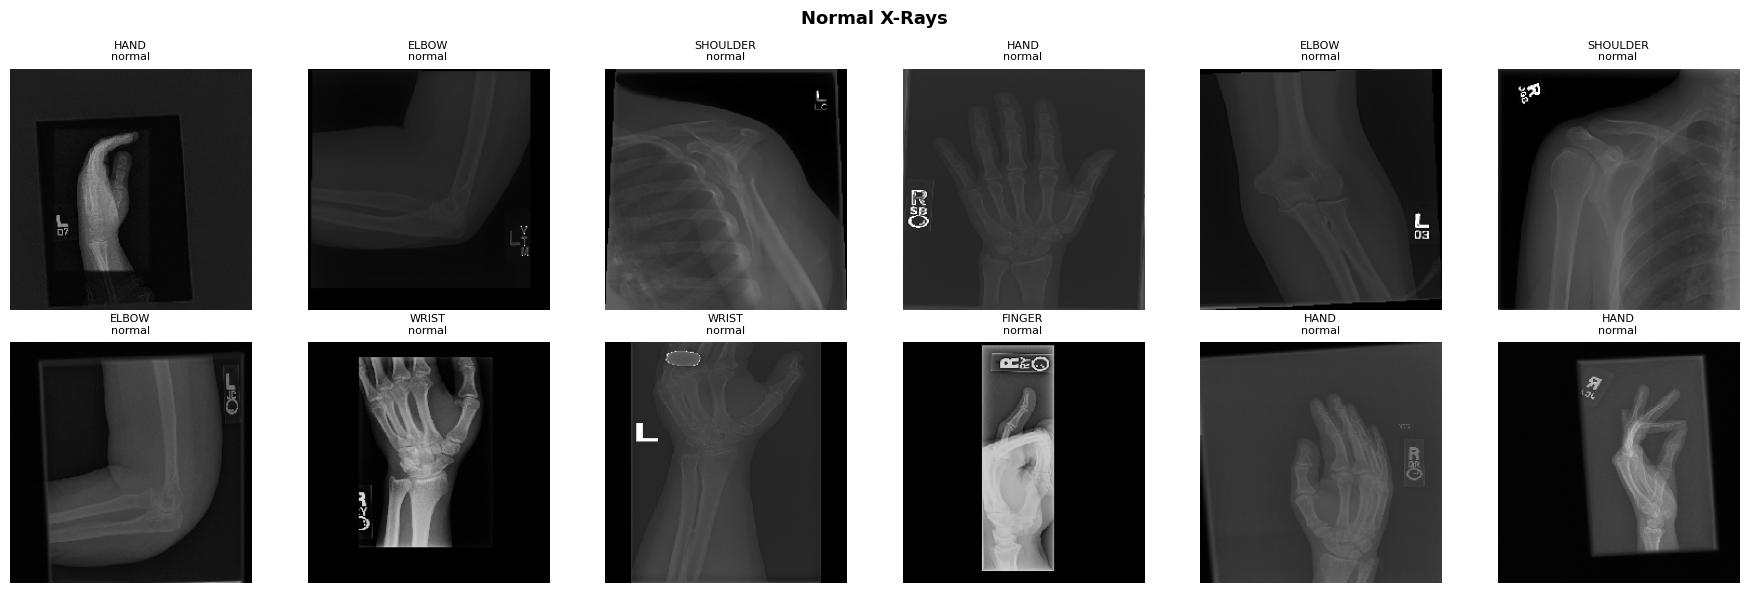

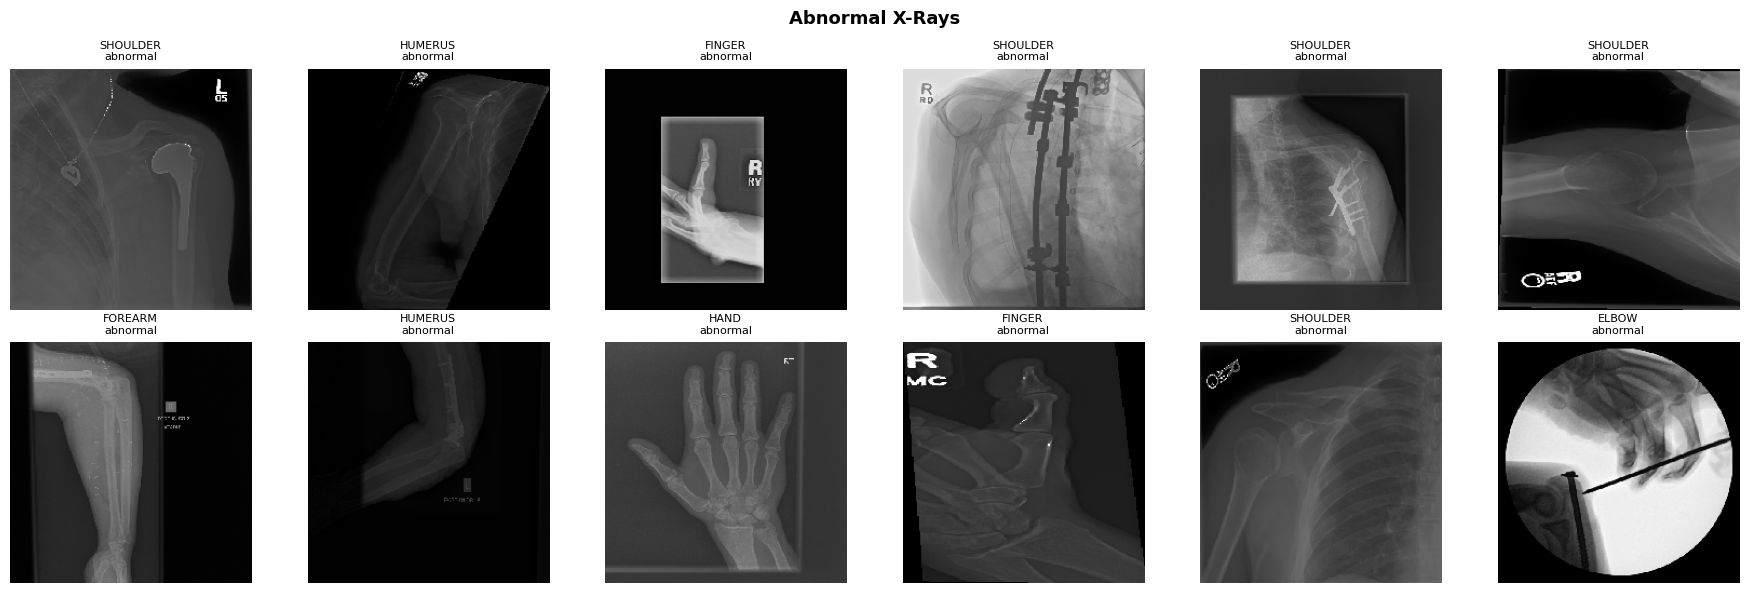

In [9]:
def show_samples(dataframe, title=''):
    sample = dataframe.sample(12, random_state=42)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = load_img(row['image_path'], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"{row['category'].replace('XR_', '')}\n{row['label_type']}", fontsize=8)
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(df[df['label_type'] == 'normal'],   title='Normal X-Rays')
show_samples(df[df['label_type'] == 'abnormal'], title='Abnormal X-Rays')

---
## Data Generators

We use Keras `ImageDataGenerator` to:
- Load images from disk in batches (avoids loading 40k images into RAM at once)
- Apply **data augmentation** on training images (random flips, rotations, zooms) to make the model more robust
- Scale pixel values from [0, 255] to [0, 1]

In [10]:
df_train = df[df['set_type'] == 'train'].reset_index(drop=True)
df_valid = df[df['set_type'] == 'valid'].reset_index(drop=True)

# Boosted class weights — penalise missing an abnormal 2x more than a false alarm
class_weight = {
    0: 1.0,   # normal
    1: 2.0,   # abnormal
}
print('Class weights:', class_weight)

# Standard rescale generator — used as fallback / for the CNN-GRU
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=True, seed=42
)
val_gen = val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'],
    shuffle=False
)

print(f'Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}')

Class weights: {0: 1.0, 1: 2.0}
Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.
Train batches: 576  |  Val batches: 50


---
## Helper Functions

Reusable functions for plotting and evaluating — shared across all models.

In [12]:
def plot_history(history, model_name=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History - {model_name}', fontsize=13, fontweight='bold')
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],          label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Validation')
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate(model, generator, model_name=''):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'{model_name} - Loss: {loss:.4f} | Accuracy: {acc:.4f}')
    return loss, acc


def plot_confusion_matrix(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))


def show_misclassified(model, generator, model_name=''):
    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    labels = list(generator.class_indices.keys())
    wrong  = np.where(y_pred != y_true)[0]
    sample = np.random.choice(wrong, min(12, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, idx in zip(axes.flat, sample):
        img = load_img(generator.filenames[idx], target_size=(IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.set_title(f"True: {labels[y_true[idx]]}\nPred: {labels[y_pred[idx]]}", fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle(f'Misclassified - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Total wrong: {len(wrong)} / {len(y_true)}')

In [13]:
def make_dataset(df, preprocess_fn, augment=False):
    """
    Build a fast tf.data pipeline.
    Used in Phase 2 of transfer learning — much faster than ImageDataGenerator
    because images are loaded in parallel on CPU while the GPU trains.
    """
    paths  = df['image_path'].values
    labels = df['label_type'].map({'normal': 0.0, 'abnormal': 1.0}).values

    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = preprocess_fn(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# Results table — one row per model, filled in as each model finishes
results_df = pd.DataFrame(columns=[
    'model', 'val_loss', 'val_accuracy',
    'precision_normal', 'recall_normal', 'f1_normal',
    'precision_abnormal', 'recall_abnormal', 'f1_abnormal',
    'epochs_trained'
])

def log_results(model, generator, model_name, history=None):
    """Evaluate model on generator and append a summary row to results_df."""
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)

    generator.reset()
    y_pred = (model.predict(generator, verbose=0) > 0.5).astype(int).flatten()
    y_true = generator.classes
    report = classification_report(y_true, y_pred,
                                   target_names=list(generator.class_indices.keys()),
                                   output_dict=True)
    global results_df
    results_df = pd.concat([results_df, pd.DataFrame([{
        'model':              model_name,
        'val_loss':           round(loss, 4),
        'val_accuracy':       round(acc, 4),
        'precision_normal':   round(report['normal']['precision'], 4),
        'recall_normal':      round(report['normal']['recall'], 4),
        'f1_normal':          round(report['normal']['f1-score'], 4),
        'precision_abnormal': round(report['abnormal']['precision'], 4),
        'recall_abnormal':    round(report['abnormal']['recall'], 4),
        'f1_abnormal':        round(report['abnormal']['f1-score'], 4),
        'epochs_trained':     len(history.history['val_loss']) if history else None,
    }])], ignore_index=True)
    print(f'Logged: {model_name}')
    display(results_df)

---
## Model 3 - EfficientNetB0 (Transfer Learning)

A second pre-trained model for comparison with DenseNet121.

**What makes EfficientNet different?**  
Traditional CNNs scale by going deeper OR wider. EfficientNet uses **compound scaling** — it scales depth, width, and image resolution together in a balanced ratio, achieving better accuracy with fewer parameters.

**Why compare it to DenseNet?**  
DenseNet was specifically tested on MURA. EfficientNet is a more general modern architecture. Comparing them lets us see whether the task benefits from a medically-motivated design.

Same two-phase training approach as DenseNet121.

In [14]:
# EfficientNet also has its own preprocessing
eff_train_datagen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    horizontal_flip=True, rotation_range=15, zoom_range=0.1,
    width_shift_range=0.1, height_shift_range=0.1
)
eff_val_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    df_train, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=True, seed=42
)
eff_val_gen = eff_val_datagen.flow_from_dataframe(
    df_valid, x_col='image_path', y_col='label_type',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', classes=['normal', 'abnormal'], shuffle=False
)

Found 36808 validated image filenames belonging to 2 classes.
Found 3197 validated image filenames belonging to 2 classes.


In [15]:
eff_base  = EfficientNetB0(include_top=False, weights='imagenet',
                           input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
x         = Dense(256, activation='relu')(eff_base.output)
x         = Dropout(0.4)(x)
eff_out   = Dense(1, activation='sigmoid')(x)
eff_model = Model(inputs=eff_base.input, outputs=eff_out)

# Phase 1: freeze the base — only the new head trains
for layer in eff_base.layers:
    layer.trainable = False

eff_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)

print('Phase 1: training the head (base frozen) ...')
eff_p1 = eff_model.fit(
    eff_train_gen, validation_data=eff_val_gen,
    epochs=5, callbacks=[es], class_weight=class_weight, verbose=1
)
print(f'Phase 1 done ({len(eff_p1.history["loss"])} epochs)')

I0000 00:00:1773249707.878586      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: training the head (base frozen) ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1773249724.142213     151 service.cc:152] XLA service 0x7e9368213fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773249724.142259     151 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773249726.498778     151 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773249746.438616     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


576/576 ━━━━━━━━━━━━━━━━━━━━ 897s 1s/step - accuracy: 0.6200 - loss: 0.8574 - val_accuracy: 0.7369 - val_loss: 0.5400
Epoch 2/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 564s 979ms/step - accuracy: 0.6932 - loss: 0.7683 - val_accuracy: 0.7344 - val_loss: 0.5262
Epoch 3/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 551s 956ms/step - accuracy: 0.7068 - loss: 0.7407 - val_accuracy: 0.7491 - val_loss: 0.5047
Epoch 4/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 544s 945ms/step - accuracy: 0.7105 - loss: 0.7365 - val_accuracy: 0.7332 - val_loss: 0.5272
Epoch 5/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 533s 925ms/step - accuracy: 0.7247 - loss: 0.7208 - val_accuracy: 0.7498 - val_loss: 0.5010
Restoring model weights from the end of the best epoch: 5.
Phase 1 done (5 epochs)


Phase 2: fine-tuning the full network ...
Epoch 1/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5621 - loss: 1.1863
Epoch 1: val_accuracy improved from -inf to 0.60557, saving model to /kaggle/working/eff_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 367s 376ms/step - accuracy: 0.5621 - loss: 1.1860 - val_accuracy: 0.6056 - val_loss: 0.7570 - learning_rate: 1.0000e-05
Epoch 2/30
575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5599 - loss: 1.1337
Epoch 2: val_accuracy improved from 0.60557 to 0.66844, saving model to /kaggle/working/eff_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - accuracy: 0.5600 - loss: 1.1331 - val_accuracy: 0.6684 - val_loss: 0.6361 - learning_rate: 1.0000e-05
Epoch 3/30
575/576 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5900 - loss: 1.0288
Epoch 3: val_accuracy improved from 0.66844 to 0.68502, saving model to /kaggle/working/eff_best.keras
576/576 ━━━━━━━━━━━━━━━━━━━━ 84s 140ms/step - accuracy: 0.5901 - loss: 1.0282 - val_accurac

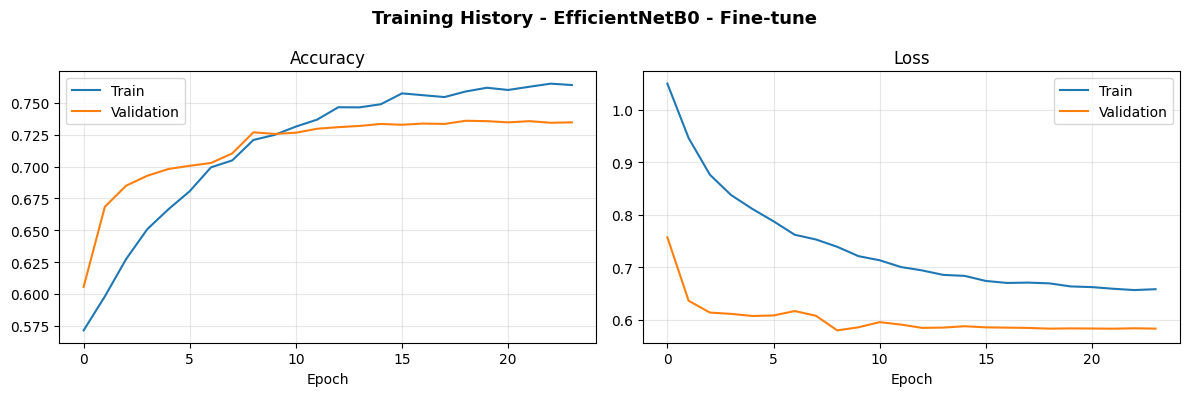

EfficientNetB0 - Loss: 0.5667 | Accuracy: 0.7316


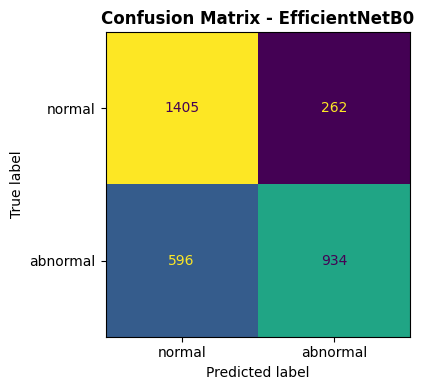

              precision    recall  f1-score   support

      normal       0.70      0.84      0.77      1667
    abnormal       0.78      0.61      0.69      1530

    accuracy                           0.73      3197
   macro avg       0.74      0.73      0.73      3197
weighted avg       0.74      0.73      0.73      3197



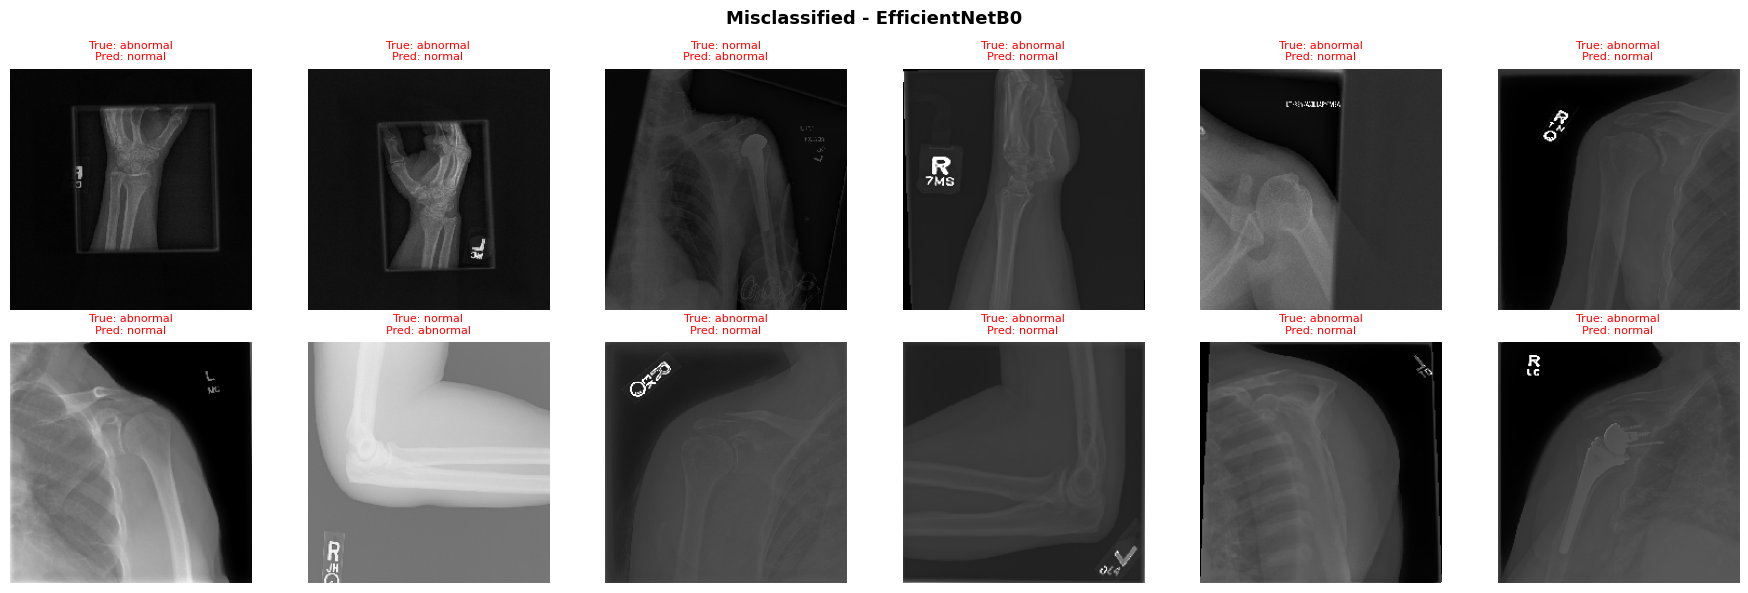

Total wrong: 858 / 3197
Logged: EfficientNetB0


/tmp/ipykernel_55/2417869877.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{


,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,EfficientNetB0,0.5667,0.7316,0.7021,0.8428,0.7661,0.7809,0.6105,0.6853,24


In [16]:
# Phase 2: unfreeze everything and fine-tune with a tiny learning rate
# Switch to tf.data pipeline — parallel image loading is significantly faster than ImageDataGenerator
eff_train_ds = make_dataset(df_train, eff_preprocess, augment=True)
eff_val_ds   = make_dataset(df_valid, eff_preprocess)

for layer in eff_base.layers:
    layer.trainable = True

SAVE_DIR = '/kaggle/working' if os.path.exists('/kaggle/input') else '/content'

eff_model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
es         = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
rlr        = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(f'{SAVE_DIR}/eff_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

print('Phase 2: fine-tuning the full network ...')
eff_p2 = eff_model.fit(
    eff_train_ds, validation_data=eff_val_ds,
    epochs=EPOCHS, callbacks=[es, rlr, checkpoint],
    class_weight=class_weight, verbose=1
)
print(f'Phase 2 done ({len(eff_p2.history["loss"])} epochs)')

plot_history(eff_p2, model_name='EfficientNetB0 - Fine-tune')
eff_eval = evaluate(eff_model, eff_val_gen, model_name='EfficientNetB0')
plot_confusion_matrix(eff_model, eff_val_gen, model_name='EfficientNetB0')
show_misclassified(eff_model, eff_val_gen, model_name='EfficientNetB0')
log_results(eff_model, eff_val_gen, model_name='EfficientNetB0', history=eff_p2)

---
## Model 4 - CNN-GRU (Study-Level Sequence Model)

An experimental architecture that treats each patient study as a **sequence of X-ray views**.

**The idea:**  
Each MURA study contains multiple images of the same body part from different angles. Instead of classifying images one by one and voting, we let the model read all views together — the GRU sees the full picture before deciding.

### How it works

```
Study: [view1, view2, view3, ..., viewN]  (padded to MAX_VIEWS=7)
  |
EfficientNetB0 (frozen, shared weights) applied to each view independently
  → feature vector per view  (shape: 1280)
  |
GRU reads the sequence of feature vectors
  → single summary hidden state
  |
Dense(1, sigmoid)  →  normal / abnormal
```

- **`TimeDistributed`** applies the same CNN to every view in the sequence
- **`Masking`** tells the GRU to ignore zero-padded slots (studies with fewer than 7 images)
- The CNN backbone is **frozen** — we only train the GRU and the final Dense layers

In [17]:
class StudySequenceGenerator(tf.keras.utils.Sequence):
    """
    Custom generator that yields one study (patient visit) at a time as a sequence of images.

    Each study = multiple X-ray views of the same body part, all sharing one label.
    Images are sorted alphabetically within each study for consistent ordering.
    Studies shorter than MAX_VIEWS are zero-padded; longer ones are truncated.

    Uses EfficientNet preprocessing (scales to [-1, 1]) to match the frozen backbone.
    """

    def __init__(self, df, batch_size=8, max_views=MAX_VIEWS, augment=False, shuffle=True):
        self.studies    = df.groupby('path')
        self.study_ids  = list(self.studies.groups.keys())
        self.batch_size = batch_size
        self.max_views  = max_views
        self.augment    = augment
        self.shuffle    = shuffle
        if shuffle:
            np.random.shuffle(self.study_ids)

    def __len__(self):
        return int(np.ceil(len(self.study_ids) / self.batch_size))

    def __getitem__(self, idx):
        batch_ids = self.study_ids[idx * self.batch_size:(idx + 1) * self.batch_size]

        X = np.zeros((len(batch_ids), self.max_views, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        y = np.zeros(len(batch_ids), dtype=np.float32)

        for i, study_path in enumerate(batch_ids):
            group = self.studies.get_group(study_path)
            image_paths = sorted(group['image_path'].tolist())[:self.max_views]

            for j, img_path in enumerate(image_paths):
                img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb')
                arr = img_to_array(img)   # keep as [0,255] — eff_preprocess handles scaling

                if self.augment:
                    if np.random.rand() > 0.5:
                        arr = arr[:, ::-1, :]   # random horizontal flip
                    angle = np.random.uniform(-15, 15)
                    arr = tf.keras.preprocessing.image.apply_affine_transform(arr, theta=angle)

                # Apply EfficientNet preprocessing: scales to [-1, 1]
                X[i, j] = eff_preprocess(arr)

            y[i] = group['label'].iloc[0]

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.study_ids)


train_seq = StudySequenceGenerator(df_train, batch_size=8, augment=True,  shuffle=True)
val_seq   = StudySequenceGenerator(df_valid, batch_size=8, augment=False, shuffle=False)

print('Train studies:', len(train_seq.study_ids))
print('Val   studies:', len(val_seq.study_ids))

Train studies: 13457
Val   studies: 1199


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 7, 224,    │          0 │ -                 │
│ (InputLayer)        │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 7, 1280)   │  4,049,571 │ input_layer_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 7, 1280)   │          0 │ time_distributed… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 7, 1280)   │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 7)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 256)       │  1,181,184 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,263,780 (20.08 MB)

 Trainable params: 1,214,209 (4.63 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


E0000 00:00:1773255242.143043      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/time_distributed_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1683/1683 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.5427 - loss: 0.9063
Epoch 1: val_accuracy improved from -inf to 0.72227, saving model to /kaggle/working/gru_best.keras
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 964s 526ms/step - accuracy: 0.5427 - loss: 0.9062 - val_accuracy: 0.7223 - val_loss: 0.5307 - learning_rate: 1.0000e-04
Epoch 2/30
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7119 - loss: 0.7535
Epoch 2: val_accuracy improved from 0.72227 to 0.78065, saving model to /kaggle/working/gru_best.keras
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 816s 485ms/step - accuracy: 0.7119 - loss: 0.7535 - val_accuracy: 0.7807 - val_loss: 0.4850 - learning_rate: 1.0000e-04
Epoch 3/30
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.7363 - loss: 0.7225
Epoch 3: val_accuracy did not improve from 0.78065
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 855s 508ms/step - accuracy: 0.7363 - loss: 0.7225 - val_accuracy: 0.7748 - val_loss: 0.4816 - learning_rate: 1.0000e-04
Epoch 4/30
1683/1683 ━━━━━━━━━━━━━

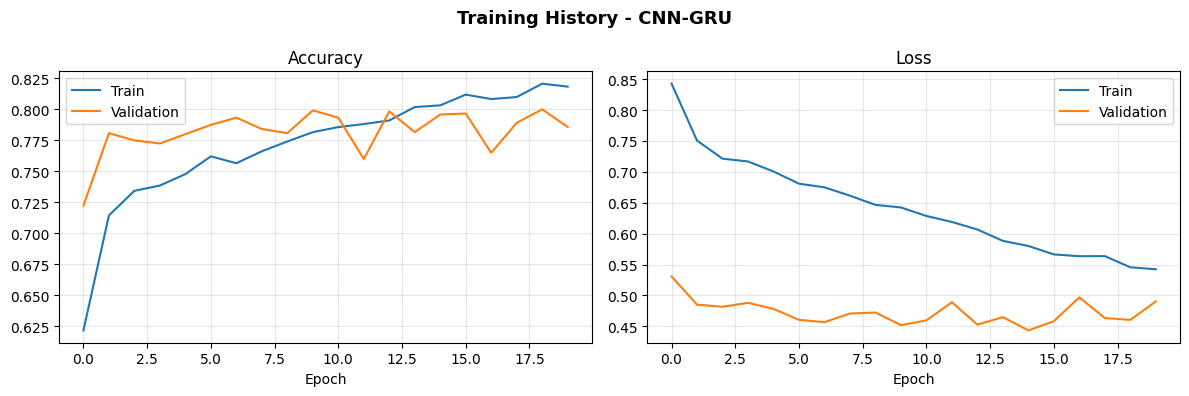

CNN-GRU - Loss: 0.4433 | Accuracy: 0.7957


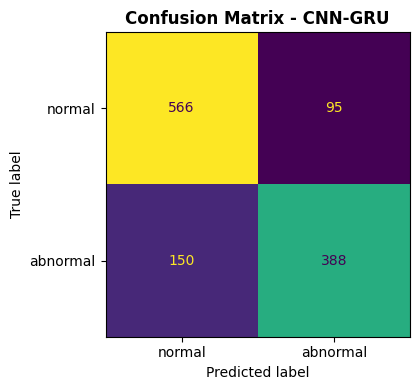

              precision    recall  f1-score   support

      normal       0.79      0.86      0.82       661
    abnormal       0.80      0.72      0.76       538

    accuracy                           0.80      1199
   macro avg       0.80      0.79      0.79      1199
weighted avg       0.80      0.80      0.79      1199



In [18]:
def build_cnn_gru():
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg',
    )
    backbone.trainable = False

    inp = Input(shape=(MAX_VIEWS, IMG_SIZE, IMG_SIZE, 3))
    x = TimeDistributed(backbone)(inp)
    x = Masking(mask_value=0.0)(x)
    x = GRU(256, return_sequences=False, dropout=0.3)(x)
    x   = Dense(128, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out)


gru_model = build_cnn_gru()
gru_model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
gru_model.summary()

SAVE_DIR = '/kaggle/working' if os.path.exists('/kaggle/input') else '/content'

es         = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
rlr        = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint(f'{SAVE_DIR}/gru_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)

gru_history = gru_model.fit(
    train_seq, validation_data=val_seq,
    epochs=EPOCHS, callbacks=[es, rlr, checkpoint],
    class_weight=class_weight,
)

plot_history(gru_history, model_name='CNN-GRU')


def evaluate_seq(model, generator, model_name=''):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'{model_name} - Loss: {loss:.4f} | Accuracy: {acc:.4f}')
    return loss, acc


def plot_confusion_matrix_seq(model, generator, model_name=''):
    y_true, y_pred = [], []
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = (model.predict(X_batch, verbose=0) > 0.5).astype(int).flatten()
        y_true.extend(y_batch.astype(int).tolist())
        y_pred.extend(preds.tolist())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    labels = ['normal', 'abnormal']
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=labels))


gru_eval = evaluate_seq(gru_model, val_seq, model_name='CNN-GRU')
plot_confusion_matrix_seq(gru_model, val_seq, model_name='CNN-GRU')

---
## Final Comparison

All 4 models evaluated on the same MURA validation set.

In [21]:
print(f"{'Model':<35} {'Val Accuracy':>14} {'Val Loss':>12}")
print('-' * 63)
for name, (loss, acc) in [
    ('EfficientNetB0 (transfer learning)', eff_eval),
    ('CNN-GRU (study-level sequence)',     gru_eval),
]:
    print(f'{name:<35} {acc:>14.4f} {loss:>12.4f}')

print()
display(results_df)

Model                                 Val Accuracy     Val Loss
---------------------------------------------------------------
EfficientNetB0 (transfer learning)          0.7316       0.5667
CNN-GRU (study-level sequence)              0.7957       0.4433



,model,val_loss,val_accuracy,precision_normal,recall_normal,f1_normal,precision_abnormal,recall_abnormal,f1_abnormal,epochs_trained
0,EfficientNetB0,0.5667,0.7316,0.7021,0.8428,0.7661,0.7809,0.6105,0.6853,24
